# Important Parameter Separation

This notebook analyzes how benign vs malicious clients affect safety-critical parameters using safety-score based masks from wandg/snip-style artifacts.

The notebook stays minimal: load the saved score artifacts, build masks, and compare client updates against a harmful reference.

In [1]:
import math
import os
import pickle
import re

import numpy as np
import torch
from tqdm import tqdm
os.environ['CUDA_VISIBLE_DEVICES'] = '6'
snip_attribution_paths = '/home/ps9044/safety-attribution/weietal/out49/llama2-7b-chat-hf/unstructured/wanda_weightonly'
utility_attribution_path = os.path.join(snip_attribution_paths, 'alpaca_cleaned_no_safety/wanda_score/alpaca_cleaned_no_safety_weight_only_disentangle')
safety_attribution_path = os.path.join(snip_attribution_paths, 'align/wanda_score/align_weight_only_disentangle')

_LORA_PARAM_RE = re.compile(r'^base_model\.model\.model\.layers\.(\d+)\.(.+)\.lora_[AB]\.weight$')


def parse_lora_param_name(param_name):
    match = _LORA_PARAM_RE.match(param_name)
    if match is None:
        return None
    layer_idx = int(match.group(1))
    module_name = match.group(2)
    return layer_idx, module_name


def score_path_for_param(param_name, attribution_root, safety=True):
    parsed = parse_lora_param_name(param_name)
    if parsed is None:
        return None
    layer_idx, module_name = parsed
    if safety:
        return os.path.join(
            attribution_root,
            # f'W_metric_layer_{layer_idx}_name_model.layers.{layer_idx}.{module_name}_weight.pkl',
            f'W_metric_layer_{layer_idx}_name_{module_name}_align_weight_only_disentangle.pkl'
        )
    else:
        return os.path.join(
            attribution_root,
            f'W_metric_layer_{layer_idx}_name_{module_name}_alpaca_cleaned_no_safety_weight_only_disentangle.pkl'
        )


def safety_score_path_for_param(param_name, attribution_root=safety_attribution_path):
    return score_path_for_param(param_name, attribution_root)


def utility_score_path_for_param(param_name, attribution_root=utility_attribution_path):
    return score_path_for_param(param_name, attribution_root, safety=False)

In [2]:
def _bottom_fraction_mask(scores, bottom_fraction):
    scores = torch.as_tensor(scores).detach().cpu().float()
    flat = scores.abs().reshape(-1)
    if flat.numel() == 0:
        return torch.zeros_like(scores, dtype=torch.bool)
    keep = max(1, int(math.ceil(flat.numel() * float(bottom_fraction))))
    threshold = torch.topk(flat, keep, largest=False).values.max()
    return scores.abs() <= threshold


def _collect_lora_pairs(local_dict):
    grouped = {}
    for param_name, param in local_dict.items():
        if not torch.is_tensor(param):
            continue
        parsed = parse_lora_param_name(param_name)
        if parsed is None:
            continue
        layer_idx, module_name = parsed
        bucket = grouped.setdefault((layer_idx, module_name), {})
        if '.lora_A.weight' in param_name:
            bucket['A'] = param.detach().cpu().float()
        elif '.lora_B.weight' in param_name:
            bucket['B'] = param.detach().cpu().float()
    return grouped


def _ordered_lora_module_keys(local_dict):
    ordered = []
    seen = set()
    for param_name in local_dict:
        parsed = parse_lora_param_name(param_name)
        if parsed is None:
            continue
        if parsed in seen:
            continue
        seen.add(parsed)
        ordered.append(parsed)
    return ordered


def _mask_cache_path(cache_dir, mode, p, q):
    if cache_dir is None:
        return None
    os.makedirs(cache_dir, exist_ok=True)
    def _tag(value):
        text = f"{float(value):.6f}".rstrip('0').rstrip('.')
        return text.replace('.', 'p') if text else '0'
    return os.path.join(cache_dir, f'mask_cache_mode{mode}_p{_tag(p)}_q{_tag(q)}.pkl')


def precompute_score_masks(
    local_dict,
    safety_root,
    utility_root=None,
    p=0.1,
    q=None,
    mode=0,
    cache_dir=None,
    force=False,
):
    if q is None:
        q = p
    grouped = _collect_lora_pairs(local_dict)
    cache_path = _mask_cache_path(cache_dir, mode, p, q)
    meta = {
        'safety_root': safety_root,
        'utility_root': utility_root,
        'p': float(p),
        'q': float(q),
        'mode': int(mode),
    }
    if cache_path and not force and os.path.exists(cache_path):
        with open(cache_path, 'rb') as handle:
            payload = pickle.load(handle)
        if payload.get('meta') == meta:
            return payload.get('masks', {}), payload.get('missing_score_paths', [])
        
    masks = {}
    missing_score_paths = []
    print('collected all lora weights')
    print(f'Example: {list(grouped.keys())[0]}')
    print(grouped[list(grouped.keys())[0]].keys())

    for (layer_idx, module_name), pair in tqdm(sorted(grouped.items())):
        if 'A' not in pair or 'B' not in pair:
            raise ValueError(f'missing A or B for layer {layer_idx} module {module_name}')
        delta_shape = (pair['B'].shape[0], pair['A'].shape[1])
        safety_path = safety_score_path_for_param(
            f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
            attribution_root=safety_root,
        )
        if safety_path is None or not os.path.exists(safety_path):
            missing_score_paths.append(safety_path)
            raise ValueError(f'safety score path not found for layer {layer_idx} module {module_name}: {safety_path}')
            continue
        with open(safety_path, 'rb') as handle:
            safety_score = pickle.load(handle)
        # print(safety_score.mean())
        safety_mask = _bottom_fraction_mask(safety_score, p)
        if safety_mask.shape != delta_shape:
            raise ValueError(
                f'mask shape mismatch for layer {layer_idx} {module_name}: '
                f'{tuple(safety_mask.shape)} vs {tuple(delta_shape)}',
            )

        utility_mask = None
        if mode == 1:
            if utility_root is None:
                raise ValueError('utility_root is required when mode=1')
            utility_path = utility_score_path_for_param(
                f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
                attribution_root=utility_root,
            )
            if utility_path is None or not os.path.exists(utility_path):
                missing_score_paths.append(utility_path)
                raise ValueError(f'utility score path not found for layer {layer_idx} module {module_name}: {utility_path}')
                continue
            with open(utility_path, 'rb') as handle:
                utility_score = pickle.load(handle)
            utility_mask = _bottom_fraction_mask(utility_score, q)
            if utility_mask.shape != delta_shape:
                raise ValueError(
                    f'utility mask shape mismatch for layer {layer_idx} {module_name}: '
                    f'{tuple(utility_mask.shape)} vs {tuple(delta_shape)}',
                )
        masks[(layer_idx, module_name)] = {
            'safety': safety_mask,
            'utility': utility_mask,
        }

    if cache_path:
        payload = {
            'meta': meta,
            'masks': masks,
            'missing_score_paths': missing_score_paths,
        }
        with open(cache_path, 'wb') as handle:
            pickle.dump(payload, handle)
    return masks, missing_score_paths


def calculate_parameter_change(
    local_dict,
    safety_root,
    utility_root=None,
    p=0.1,
    q=None,
    mode=0,
    precomputed_masks=None,
    reference_data=None,
):
    """Compute masked delta-W norms for LoRA modules.

    mode=0: keep the smallest p-fraction of safety scores.
    mode=1: keep the smallest p-fraction of safety scores and remove the smallest q-fraction of utility scores.
    """
    if q is None:
        q = p

    grouped = _collect_lora_pairs(local_dict)
    ordered_keys = _ordered_lora_module_keys(local_dict)
    if len(ordered_keys) != len(grouped):
        ordered_keys = sorted(grouped.keys())
    if reference_data is None:
        raise ValueError('reference_data is required for cosine similarity')
    if len(reference_data) != len(ordered_keys):
        raise ValueError(
            f'reference_data length {len(reference_data)} does not match '
            f'lora module count {len(ordered_keys)}',
        )

    module_stats = []
    missing_score_paths = []

    for ref_idx, (layer_idx, module_name) in enumerate(ordered_keys):
        pair = grouped.get((layer_idx, module_name))
        if pair is None:
            raise ValueError(f'missing A or B for layer {layer_idx} module {module_name}')
        if 'A' not in pair or 'B' not in pair:
            raise ValueError(f'missing A or B for layer {layer_idx} module {module_name}')

        assert pair['B'].shape[1] < 50
        delta_w = pair['B'] @ pair['A']
        # mask = torch.ones_like(delta_w, dtype=torch.bool)
        
        safety_path = None
        utility_path = None
        mask_entry = None
        if precomputed_masks is not None:
            mask_entry = precomputed_masks.get((layer_idx, module_name))


        if mask_entry is not None:
            safety_mask = mask_entry['safety']
            utility_mask = mask_entry.get('utility')
        else:
            safety_path = safety_score_path_for_param(
                f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
                attribution_root=safety_root,
            )
            if safety_path is None or not os.path.exists(safety_path):
                missing_score_paths.append(safety_path)
                continue
            with open(safety_path, 'rb') as handle:
                safety_score = pickle.load(handle)
            safety_mask = _bottom_fraction_mask(safety_score, p)
            utility_mask = None
            if mode == 1:
                if utility_root is None:
                    raise ValueError('utility_root is required when mode=1')
                utility_path = utility_score_path_for_param(
                    f'base_model.model.model.layers.{layer_idx}.{module_name}.lora_A.weight',
                    attribution_root=utility_root,
                )
                if utility_path is None or not os.path.exists(utility_path):
                    missing_score_paths.append(utility_path)
                    continue
                with open(utility_path, 'rb') as handle:
                    utility_score = pickle.load(handle)
                utility_mask = _bottom_fraction_mask(utility_score, q)

        if safety_mask.shape != delta_w.shape:
            raise ValueError(
                f'mask shape mismatch for layer {layer_idx} {module_name}: '
                f'{tuple(safety_mask.shape)} vs {tuple(delta_w.shape)}',
            )

        mask = safety_mask
        if mode == 1:
            if utility_mask is None:
                raise ValueError(f'utility mask missing for layer {layer_idx} {module_name}')
            if utility_mask.shape != delta_w.shape:
                raise ValueError(
                    f'utility mask shape mismatch for layer {layer_idx} {module_name}: '
                    f'{tuple(utility_mask.shape)} vs {tuple(delta_w.shape)}',
                )
            mask = safety_mask & (~utility_mask)

        print(mask.sum(), mask.numel())
        masked_delta = delta_w[mask]
        reference_vec = reference_data[ref_idx]
        # mask the reference as well
        reference_vec = reference_vec[mask]
        cosine_sim = torch.nn.functional.cosine_similarity(
            masked_delta.flatten(),
            -reference_vec.flatten(),
            dim=0,
        ) 

        module_stats.append(
            {
                'layer_idx': layer_idx,
                'module_name': module_name,
                'safety_score_path': safety_path,
                'utility_score_path': utility_path,
                'masked_l2': float(torch.linalg.norm(masked_delta).item()),
                'cosine_sim': float(cosine_sim.item()),
                'masked_l1_mean': float(masked_delta.abs().mean().item()) if masked_delta.numel() else 0.0,
                'masked_numel': int(masked_delta.numel()),
                'total_numel': int(delta_w.numel()),
            }
        )

    return {
        'n_lora_modules': int(len(grouped)),
        'n_scored_modules': int(len(module_stats)),
        'total_masked_l2': float(sum(item['masked_l2'] for item in module_stats)),
        'mean_masked_l1': float(np.mean([item['masked_l1_mean'] for item in module_stats])) if module_stats else 0.0,
        'module_stats': module_stats,
        'missing_score_paths': missing_score_paths,
        'cosine_sim_sum': float(np.sum([item['cosine_sim'] for item in module_stats])) if module_stats else 0.0,
    }

In [3]:
example_param_name = 'base_model.model.model.layers.0.self_attn.q_proj.lora_A.weight'
print(safety_score_path_for_param(example_param_name))

run_save = '/scratch/ps9044/newsetting/BeaverTailsSafe5_BeaverTails5_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20260517123537'
sparsity = 0.05
mask_mode = 0  # 0 = safety only, 1 = safety minus utility
benign_clients = {0, 1, 2, 3, 4}
roundwise_param_changes = []
mask_cache_dir = os.path.join(run_save, 'mask_cache') if run_save else None
precomputed_masks = None
mask_cache_missing = []
reference_path = '/home/ps9044/RPA/fedllm-attack/delta_matrix_purebad10rounds_harmful_torch.float32.pkl'

# key = 'cosine_sim_sum'
key = 'total_masked_l2'
with open(reference_path, 'rb') as f:
    reference_data = pickle.load(f)

if run_save:
    for round_idx in tqdm(range(1, 31)):
        round_path = os.path.join(run_save, f'round_{round_idx}.pkl')
        if not os.path.exists(round_path):
            continue
        with open(round_path, 'rb') as f:
            data = pickle.load(f)
        if precomputed_masks is None:
            seed_client = data['clients'][0]
            precomputed_masks, mask_cache_missing = precompute_score_masks(
                data['local_dict_list'][seed_client],
                safety_root=safety_attribution_path,
                utility_root=utility_attribution_path,
                p=sparsity,
                q=sparsity,
                mode=mask_mode,
                cache_dir=mask_cache_dir,
                force=True
            )
        round_param_changes = []
        for client in data['clients']:
            summary = calculate_parameter_change(
                data['local_dict_list'][client],
                safety_root=safety_attribution_path,
                utility_root=utility_attribution_path,
                p=sparsity,
                q=sparsity,
                mode=mask_mode,
                precomputed_masks=precomputed_masks,
                reference_data=reference_data
            )
            summary['client'] = client
            summary['group'] = 'benign' if client in benign_clients else 'malicious'
            round_param_changes.append(summary)
            print(f'Client {client} | {key}: {summary[key]}')
        roundwise_param_changes.append(round_param_changes)

preview = None
if roundwise_param_changes and roundwise_param_changes[0]:
    first = roundwise_param_changes[0][0]
    preview = {
        'client': first['client'],
        'group': first['group'],
        'n_lora_modules': first['n_lora_modules'],
        'n_scored_modules': first['n_scored_modules'],
        'total_masked_l2': first['total_masked_l2'],
        'mean_masked_l1': first['mean_masked_l1'],
        'missing_score_paths': len(first['missing_score_paths']),
        'cosine_sim_sum': first['cosine_sim_sum'],
    }

print({
    'rounds_loaded': len(roundwise_param_changes),
    'preview': preview,
    'mask_cache_missing': len(mask_cache_missing),
})

/home/ps9044/safety-attribution/weietal/out49/llama2-7b-chat-hf/unstructured/wanda_weightonly/align/wanda_score/align_weight_only_disentangle/W_metric_layer_0_name_self_attn.q_proj_align_weight_only_disentangle.pkl


  0%|          | 0/30 [00:00<?, ?it/s]

collected all lora weights
Example: (0, 'self_attn.q_proj')
dict_keys(['A', 'B'])


100%|██████████| 64/64 [00:32<00:00,  2.00it/s]


tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838863) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838864) 16777216
tensor(838864) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 1

...

tensor(838864) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
Client 9 | cosine_sim_sum: 11.142556846141815
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838863) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838864) 16777216
tensor(838864) 167

 97%|█████████▋| 29/30 [12:36<00:24, 24.12s/it]

tensor(838863) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
Client 9 | cosine_sim_sum: 11.13380541652441
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838863) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838861) 16777216
tensor(838862) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838861) 16777216
tensor(838863) 16777216
tensor(838864) 16777216
tensor(838864) 16777216
tensor(838861) 16777216
tensor(838862) 1677

100%|██████████| 30/30 [13:00<00:00, 26.03s/it]

tensor(838861) 16777216
tensor(838861) 16777216
Client 9 | cosine_sim_sum: 11.128930896520615
{'rounds_loaded': 30, 'preview': {'client': 0, 'group': 'benign', 'n_lora_modules': 64, 'n_scored_modules': 64, 'total_masked_l2': 0.9922139579430223, 'mean_masked_l1': 1.3154771309586977e-05, 'missing_score_paths': 0, 'cosine_sim_sum': 9.130107641220093}, 'mask_cache_missing': 0}


0.9922139579430223
1.6123420111835003
1.8700989466160536
2.0419631004333496
2.1943516340106726
2.321093749254942
2.442510824650526
2.5452605579048395
2.6416547298431396
2.735026629641652
2.8017325066030025
2.8790566734969616
2.9397400971502066
2.994633613154292
3.0485292989760637
3.0942833088338375
3.132932871580124
3.172707114368677
3.201591309159994
3.2302772998809814
3.250026371330023
3.269346073269844
3.282369989901781
3.296132657676935
3.306318126618862
3.315156579017639
3.320970680564642
3.324079781770706
3.327221028506756
3.3289848528802395
1.2830318082123995
1.8109723348170519
2.1271454617381096
2.3051610942929983
2.4507902190089226
2.5790641121566296
2.689723540097475
2.778870588168502
2.8625695277005434
2.9384118504822254
2.988279726356268
3.040288984775543
3.089031882584095
3.131525456905365
3.1633797883987427
3.189845487475395
3.219775814563036
3.241295915096998
3.261650014668703
3.2760922759771347
3.2877482436597347
3.297715838998556
3.3059995770454407
3.3129468001425266
3

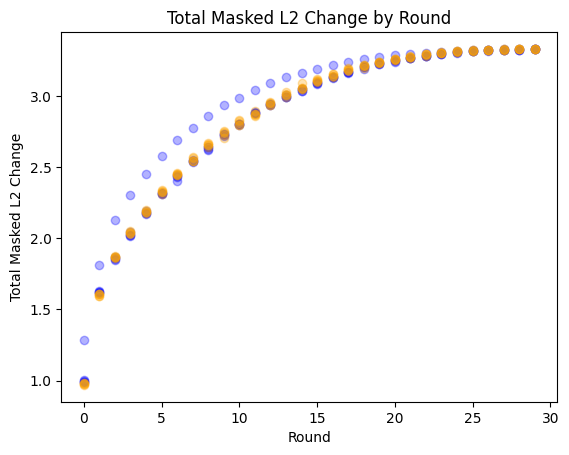

In [6]:
# plot 
import matplotlib.pyplot as plt
benigns = [0, 1, 2, 3, 4]
key = 'total_masked_l2'

for client in range(10):
    round_datas = []
    for round, round_data in enumerate(roundwise_param_changes):
        # for client_data in round_data:
        #     if client_data['client'] == client:
        #         round_datas.append(client_data[key])
        #         break
        client_data = [d for d in round_data if d['client'] == client][0]
        print(client_data[key])
        
        # print(round_datas)
        if client in benigns:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (benign)', marker='o', color='blue', alpha=0.3)
        else:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (malicious)', marker='o', color='orange', alpha=0.3)

        
plt.xlabel('Round')
plt.ylabel('Total Masked L2 Change')
plt.title('Total Masked L2 Change by Round')
# plt.ylabel('Cosine with Reference Original')
# plt.title('Cosine Similarity with Reference Original by Round')
plt.show()


In [18]:
print(key)
key = 'cosine_sim_sum'

total_masked_l2


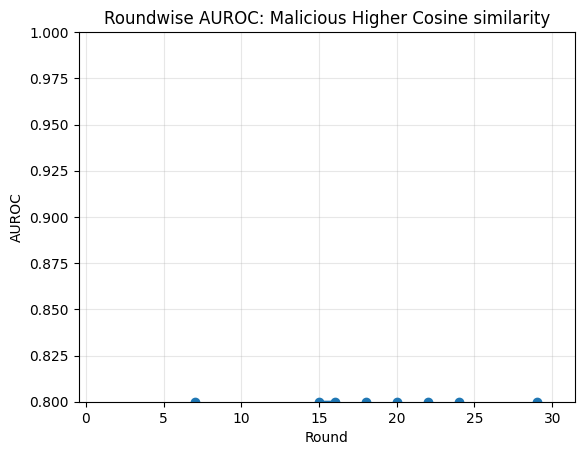

In [7]:
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

roundwise_aurocs = []

for round_idx, round_data in enumerate(roundwise_param_changes, start=1):
    y_true = []
    y_score = []

    for client_data in round_data:
        client = client_data['client']

        # malicious = 1, benign = 0
        y_true.append(0 if client in benign_clients else 1)

        # higher L2 means more malicious
        y_score.append(client_data[key])

    if len(set(y_true)) == 2:
        auroc = roc_auc_score(y_true, y_score)
    else:
        auroc = np.nan

    roundwise_aurocs.append(auroc)

plt.figure()
plt.plot(
    range(1, len(roundwise_aurocs) + 1),
    roundwise_aurocs,
    marker='o'
)
plt.xlabel('Round')
plt.ylabel('AUROC')
plt.title('Roundwise AUROC: Malicious Higher Cosine similarity')
plt.ylim(0.8, 1)
plt.grid(True, alpha=0.3)
plt.show()

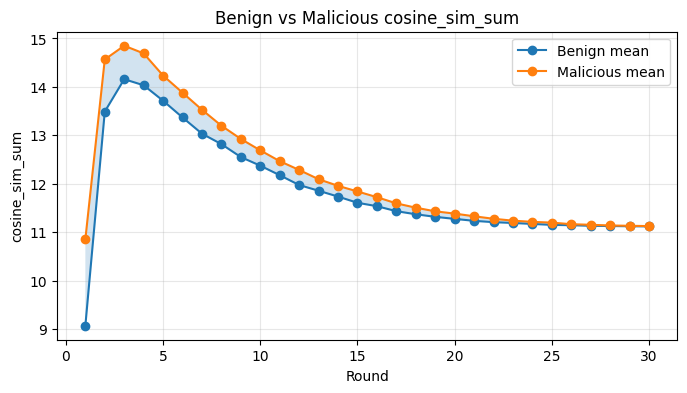

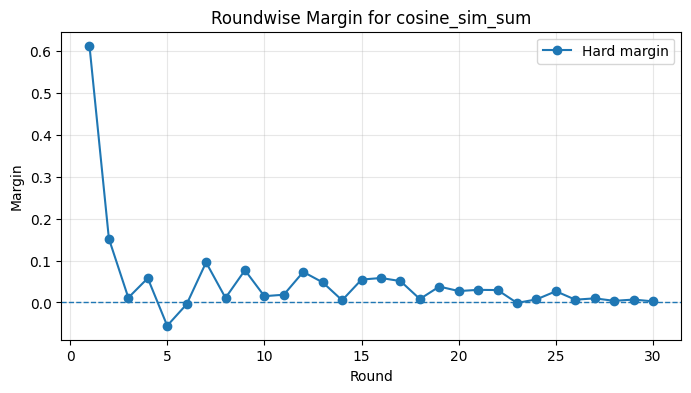

In [20]:
import numpy as np
import matplotlib.pyplot as plt

rounds = []
benign_means = []
mal_means = []
mean_margins = []
hard_margins = []

for r, round_data in enumerate(roundwise_param_changes, start=1):
    benign_scores = []
    mal_scores = []

    for client_data in round_data:
        score = client_data[key]

        if client_data["client"] in benign_clients:
            benign_scores.append(score)
        else:
            mal_scores.append(score)

    if len(benign_scores) == 0 or len(mal_scores) == 0:
        continue

    benign_scores = np.array(benign_scores)
    mal_scores = np.array(mal_scores)

    rounds.append(r)
    benign_means.append(benign_scores.mean())
    mal_means.append(mal_scores.mean())

    mean_margins.append(mal_scores.mean() - benign_scores.mean())
    hard_margins.append(mal_scores.min() - benign_scores.max())

plt.figure(figsize=(8, 4))
plt.plot(rounds, benign_means, marker="o", label="Benign mean")
plt.plot(rounds, mal_means, marker="o", label="Malicious mean")
plt.fill_between(rounds, benign_means, mal_means, alpha=0.2)
plt.xlabel("Round")
plt.ylabel(key)
plt.title(f"Benign vs Malicious {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
# plt.plot(rounds, mean_margins, marker="o", label="Mean margin")
plt.plot(rounds, hard_margins, marker="o", label="Hard margin")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Round")
plt.ylabel("Margin")
plt.title(f"Roundwise Margin for {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

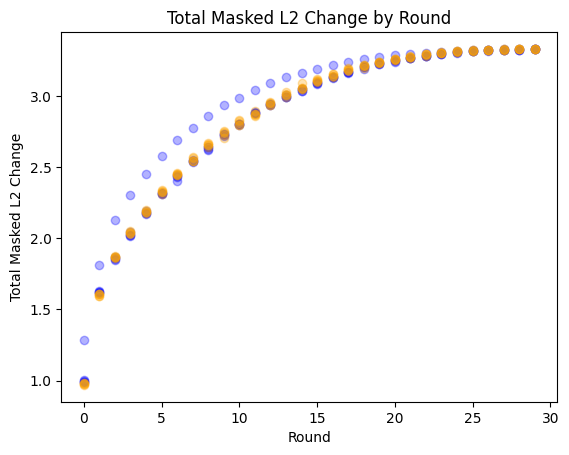

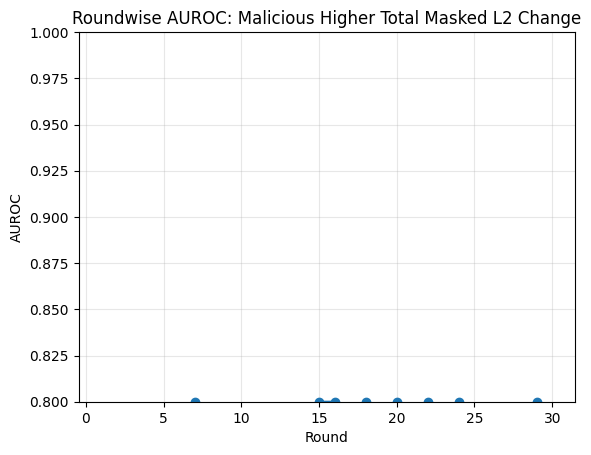

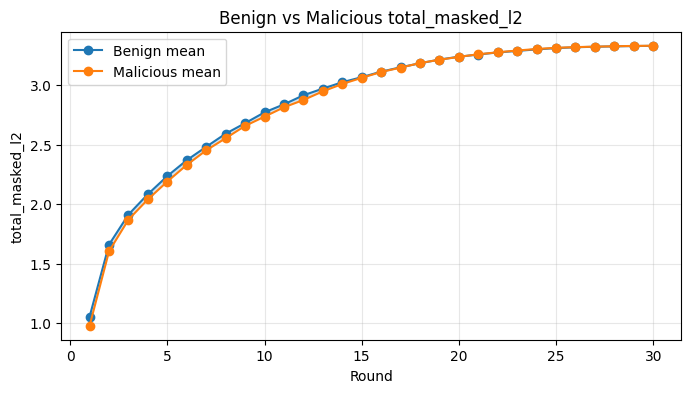

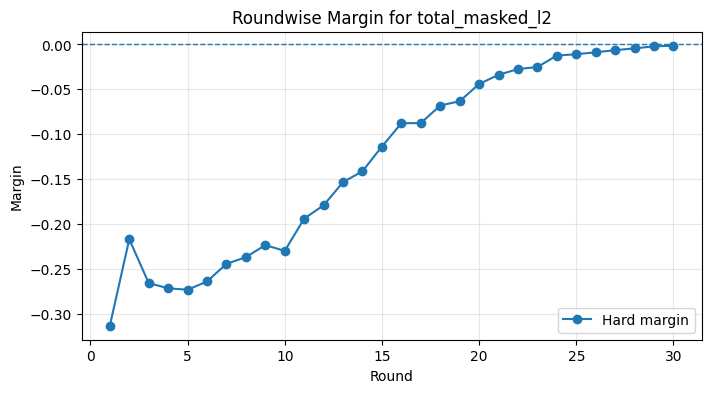

In [21]:

key = 'total_masked_l2'

# plot 

import matplotlib.pyplot as plt
benigns = [0, 1, 2, 3, 4]

for client in range(10):
    round_datas = []
    for round, round_data in enumerate(roundwise_param_changes):
        for client_data in round_data:
            if client_data['client'] == client:
                round_datas.append(client_data['total_masked_l2'])
                break
        # print(round_datas)
        if client in benigns:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (benign)', marker='o', color='blue', alpha=0.3)
        else:
            # pass
            plt.scatter(round, client_data[key], label=f'Client {client} (malicious)', marker='o', color='orange', alpha=0.3)

        
plt.xlabel('Round')
plt.ylabel('Total Masked L2 Change')
plt.title('Total Masked L2 Change by Round')
# plt.ylabel('Cosine with Reference Original')
# plt.title('Cosine Similarity with Reference Original by Round')
plt.show()


from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

roundwise_aurocs = []

for round_idx, round_data in enumerate(roundwise_param_changes, start=1):
    y_true = []
    y_score = []

    for client_data in round_data:
        client = client_data['client']

        # malicious = 1, benign = 0
        y_true.append(0 if client in benign_clients else 1)

        # higher L2 means more malicious
        y_score.append(client_data[key])

    if len(set(y_true)) == 2:
        auroc = roc_auc_score(y_true, y_score)
    else:
        auroc = np.nan

    roundwise_aurocs.append(auroc)

plt.figure()
plt.plot(
    range(1, len(roundwise_aurocs) + 1),
    roundwise_aurocs,
    marker='o'
)
plt.xlabel('Round')
plt.ylabel('AUROC')
plt.title('Roundwise AUROC: Malicious Higher Total Masked L2 Change')
plt.ylim(0.8, 1)
plt.grid(True, alpha=0.3)
plt.show()

import numpy as np
import matplotlib.pyplot as plt

rounds = []
benign_means = []
mal_means = []
mean_margins = []
hard_margins = []

for r, round_data in enumerate(roundwise_param_changes, start=1):
    benign_scores = []
    mal_scores = []

    for client_data in round_data:
        score = client_data[key]

        if client_data["client"] in benign_clients:
            benign_scores.append(score)
        else:
            mal_scores.append(score)

    if len(benign_scores) == 0 or len(mal_scores) == 0:
        continue

    benign_scores = np.array(benign_scores)
    mal_scores = np.array(mal_scores)

    rounds.append(r)
    benign_means.append(benign_scores.mean())
    mal_means.append(mal_scores.mean())

    mean_margins.append(mal_scores.mean() - benign_scores.mean())
    hard_margins.append(mal_scores.min() - benign_scores.max())

plt.figure(figsize=(8, 4))
plt.plot(rounds, benign_means, marker="o", label="Benign mean")
plt.plot(rounds, mal_means, marker="o", label="Malicious mean")
plt.fill_between(rounds, benign_means, mal_means, alpha=0.2)
plt.xlabel("Round")
plt.ylabel(key)
plt.title(f"Benign vs Malicious {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
# plt.plot(rounds, mean_margins, marker="o", label="Mean margin")
plt.plot(rounds, hard_margins, marker="o", label="Hard margin")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Round")
plt.ylabel("Margin")
plt.title(f"Roundwise Margin for {key}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()